In [1]:

!pip install estimator
!pip install --upgrade qiskit-machine-learning
!pip install qiskit qiskit-machine-learning qiskit-aer
!pip install estimator
!pip install pylatexenc


Building quantum circuit...


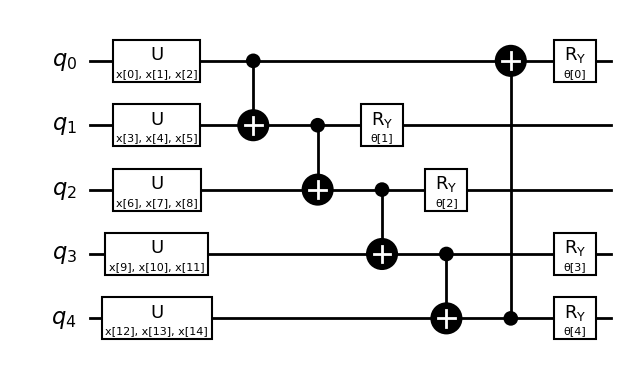

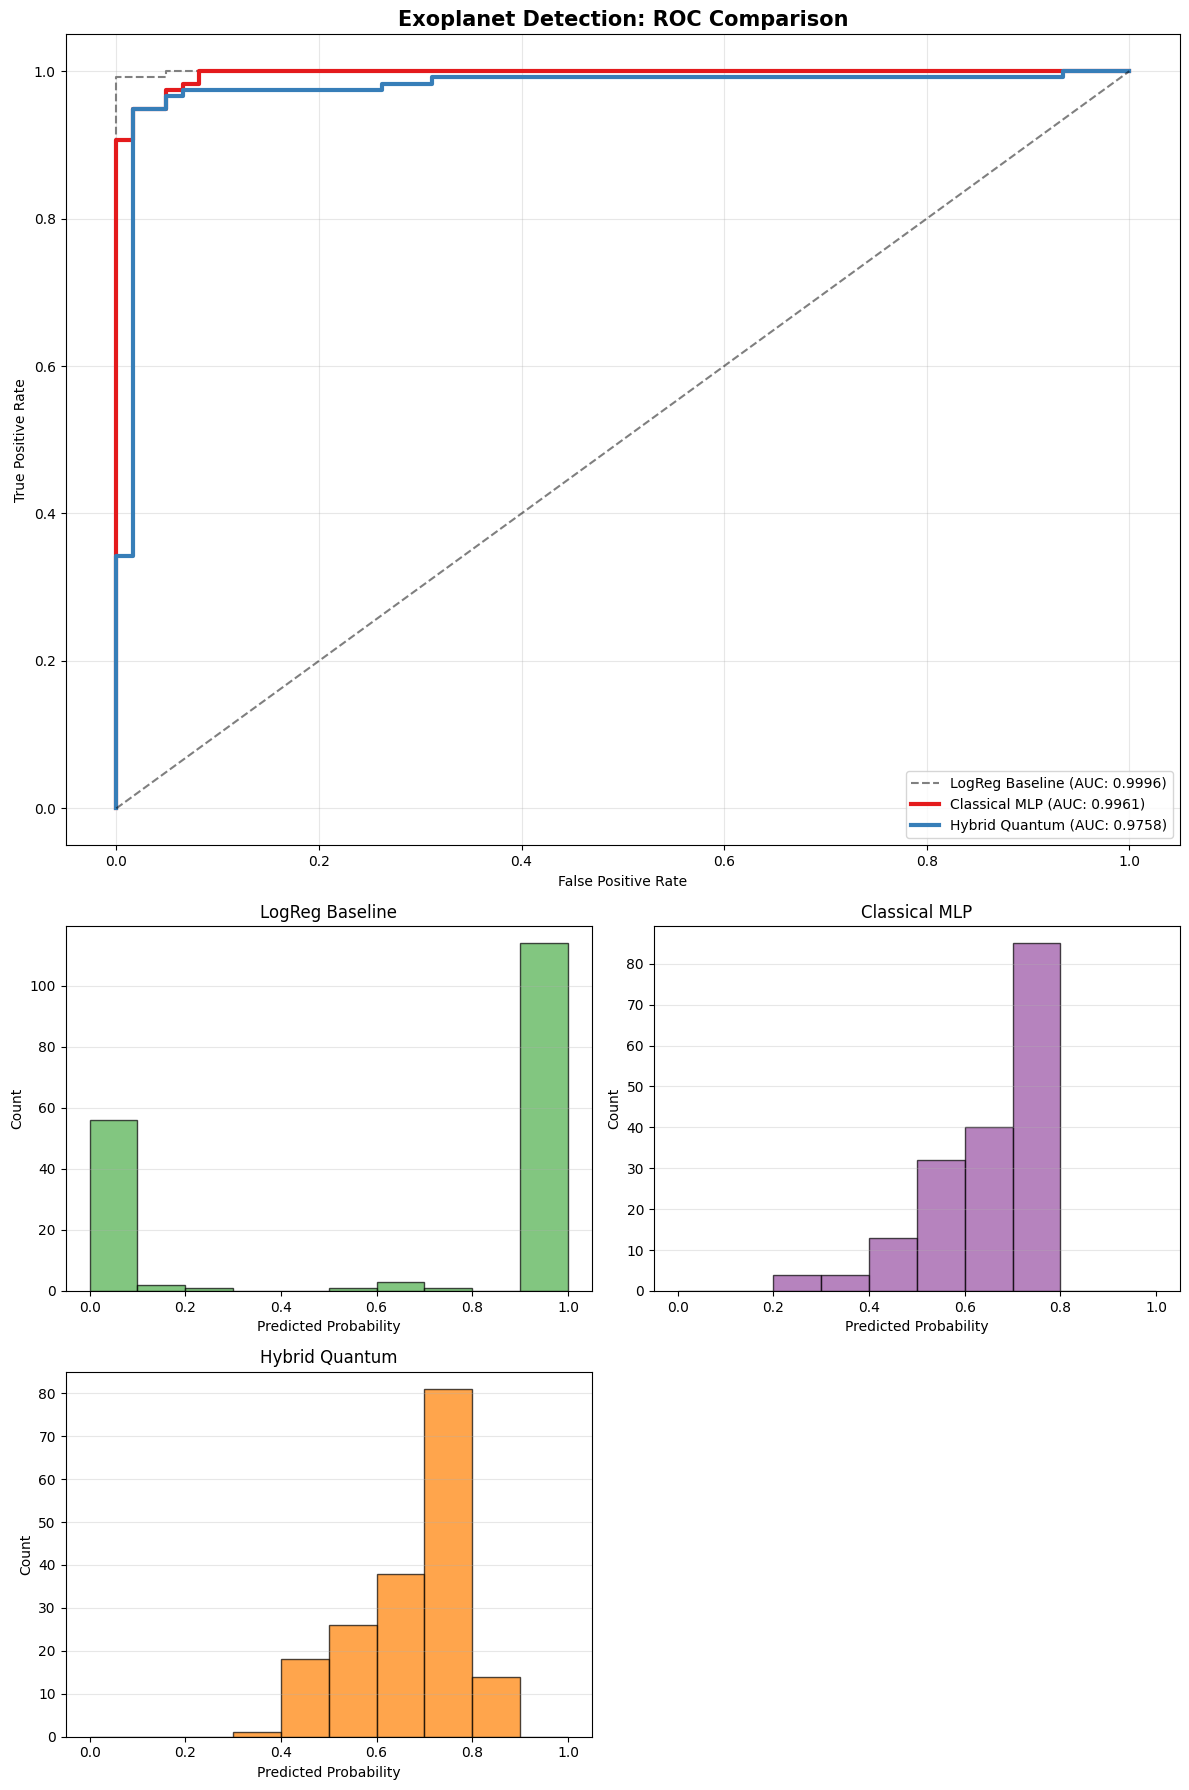


--- Results Table ---

             LogReg        NN    Hybrid
Accuracy   0.977528  0.775281  0.752809
F1         0.983051  0.854015  0.840580
Recall     0.991453  1.000000  0.991453
Precision  0.974790  0.745223  0.729560
AUROC      0.999580  0.996077  0.975760


In [2]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

import torch
import torch.nn as nn
import torch.optim as optim

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, roc_auc_score, roc_curve
from sklearn.decomposition import PCA

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator
from qiskit_machine_learning.neural_networks import EstimatorQNN


# yeah... hardcoded path (should probably fix this later)
DATA_PATH = "/content/Copy train_data - train_data.csv.csv"

FEATURE_COLUMNS = [
    'koi_score', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec',
    'koi_teq', 'koi_impact', 'koi_tce_plnt_num', 'koi_depth',
    'koi_steff', 'koi_prad', 'koi_fpflag_nt', 'koi_model_snr',
    'koi_slogg', 'koi_insol', 'koi_kepmag',
    'koi_period', 'koi_time0bk', 'koi_duration', 'ra', 'dec'
]


def load_dataset(csv_path):
    df = pd.read_csv(csv_path)

    valid_cols = [c for c in FEATURE_COLUMNS if c in df.columns]

    if 'target' not in df.columns:
        if 'koi_disposition' in df.columns:
            df['target'] = df['koi_disposition'].apply(
                lambda val: 1 if val == 'CONFIRMED' else 0
            )

    df = df[valid_cols + ['target']].dropna()

    X = df[valid_cols].values
    y = df['target'].values.astype(int)

    return X, y, valid_cols


def preprocess(Xtr, Xte, use_pca=False, pca_k=None):
    scaler = StandardScaler()
    Xtr_scaled = scaler.fit_transform(Xtr)
    Xte_scaled = scaler.transform(Xte)

    feat_count = Xtr_scaled.shape[1]

    if use_pca:
        if pca_k is None:
            pca_k = 0.95

        pca = PCA(n_components=pca_k)

        Xtr_scaled = pca.fit_transform(Xtr_scaled)
        Xte_scaled = pca.transform(Xte_scaled)

        feat_count = pca.n_components_

    # scaling to angle range for quantum circuit
    angle_scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
    Xtr_angles = angle_scaler.fit_transform(Xtr_scaled)
    Xte_angles = angle_scaler.transform(Xte_scaled)

    return Xtr_angles, Xte_angles, feat_count


def build_quantum_circuit(n_features=15, n_qubits=5):
    feats_per_q = 3
    usable_inputs = min(n_features, n_qubits * feats_per_q)

    x_params = ParameterVector('x', usable_inputs)
    theta_params = ParameterVector('θ', n_qubits)

    qc = QuantumCircuit(n_qubits)

    for q in range(n_qubits):
        base_idx = q * feats_per_q

        qc.u(
            x_params[base_idx % usable_inputs],
            x_params[(base_idx + 1) % usable_inputs],
            x_params[(base_idx + 2) % usable_inputs],
            q
        )

    for i in range(n_qubits - 1):
        qc.cx(i, i + 1)

    qc.cx(n_qubits - 1, 0)  # closing the loop

    for i in range(n_qubits):
        qc.ry(theta_params[i], i)

    return qc, x_params, theta_params


class SimpleNN(nn.Module):
    def __init__(self, input_size):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.layers(x)


def train_nn(Xtr, Xte, ytr, yte, epochs=30):
    Xtr_t = torch.tensor(Xtr, dtype=torch.float32)
    ytr_t = torch.tensor(ytr, dtype=torch.float32).view(-1, 1)

    model = SimpleNN(Xtr.shape[1])

    optimizer = optim.Adam(model.parameters(), lr=0.002)
    loss_fn = nn.BCELoss()

    for ep in range(epochs):
        model.train()

        optimizer.zero_grad()
        outputs = model(Xtr_t)
        loss = loss_fn(outputs, ytr_t)

        loss.backward()
        optimizer.step()

        # if ep % 10 == 0:
        #     print(ep, loss.item())

    model.eval()

    with torch.no_grad():
        probs = model(torch.tensor(Xte, dtype=torch.float32)).numpy().flatten()
        preds = (probs > 0.5).astype(int)

    results = {
        "Accuracy": accuracy_score(yte, preds),
        "F1": f1_score(yte, preds),
        "Recall": recall_score(yte, preds),
        "Precision": precision_score(yte, preds),
        "AUROC": roc_auc_score(yte, probs)
    }

    fpr, tpr, _ = roc_curve(yte, probs)

    return results, fpr, tpr, probs, model


def run_lr(Xtr, Xte, ytr, yte):
    lr = LogisticRegression(max_iter=1000)
    lr.fit(Xtr, ytr)

    probs = lr.predict_proba(Xte)[:, 1]
    preds = lr.predict(Xte)

    results = {
        "Accuracy": accuracy_score(yte, preds),
        "F1": f1_score(yte, preds),
        "Recall": recall_score(yte, preds),
        "Precision": precision_score(yte, preds),
        "AUROC": roc_auc_score(yte, probs)
    }

    fpr, tpr, _ = roc_curve(yte, probs)

    return results, fpr, tpr, probs, lr



def plot_results(nn_res, hybrid_res, lr_res):
    res_n, fpr_n, tpr_n, probs_n, _ = nn_res
    res_h, fpr_h, tpr_h, probs_h, _ = hybrid_res
    res_l, fpr_l, tpr_l, probs_l, _ = lr_res

    fig = plt.figure(figsize=(12, 18))
    gs  = GridSpec(4, 2)
    colors = plt.get_cmap("Set1")

    ax_roc = fig.add_subplot(gs[:2, :2])
    ax_roc.plot(fpr_l, tpr_l, color='gray', linestyle='--',
                label=f'LogReg Baseline (AUC: {res_l["AUROC"]:.4f})')
    ax_roc.plot(fpr_n, tpr_n, color=colors(0), lw=3,
                label=f'Classical MLP (AUC: {res_n["AUROC"]:.4f})')
    ax_roc.plot(fpr_h, tpr_h, color=colors(1), lw=3,
                label=f'Hybrid Quantum (AUC: {res_h["AUROC"]:.4f})')
    ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    ax_roc.set_title("Exoplanet Detection: ROC Comparison", fontsize=15, fontweight='bold')
    ax_roc.set_xlabel("False Positive Rate")
    ax_roc.set_ylabel("True Positive Rate")
    ax_roc.legend(loc="lower right")
    ax_roc.grid(True, alpha=0.3)

    grid_positions = [(2, 0), (2, 1), (3, 0)]
    titles         = ["LogReg Baseline", "Classical MLP", "Hybrid Quantum"]
    all_probs      = [probs_l, probs_n, probs_h]

    for i in range(3):
        row, col = grid_positions[i]
        ax = fig.add_subplot(gs[row, col])
        ax.hist(all_probs[i], range=(0, 1), bins=10,
                color=colors(i+2), edgecolor='black', alpha=0.7)
        ax.set(title=titles[i], xlabel="Predicted Probability", ylabel="Count")
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()


def main_run(sample_frac=1.0, use_pca=True, pca_dim=15, seed=42):
    X_all, y_all, feat_names = load_dataset(DATA_PATH)

    if sample_frac < 1.0:
        n = int(len(y_all) * sample_frac)

        X_all, _, y_all, _ = train_test_split(
            X_all, y_all,
            train_size=n,
            stratify=y_all,
            random_state=seed
        )

    Xtr, Xte, ytr, yte = train_test_split(
        X_all, y_all,
        test_size=0.2,
        random_state=seed,
        stratify=y_all
    )

    Xtr_p, Xte_p, final_dim = preprocess(
        Xtr, Xte,
        use_pca=use_pca,
        pca_k=pca_dim
    )

    print("Building quantum circuit...")
    qc, xvec, thetavec = build_quantum_circuit(final_dim, 5)

    display(qc.draw(output='mpl', style='bw'))

    res_lr = run_lr(Xtr_p, Xte_p, ytr, yte)
    res_nn = train_nn(Xtr_p, Xte_p, ytr, yte)

    n_q = 5
    observables = []

    for i in range(n_q):
        label = "I" * (n_q - 1 - i) + "Z" + "I" * i
        observables.append(SparsePauliOp.from_list([(label, 1)]))

    qnn = EstimatorQNN(
        circuit=qc,
        observables=observables,
        input_params=list(xvec),
        weight_params=list(thetavec),
        estimator=StatevectorEstimator()
    )

    rand_w = np.random.rand(qnn.num_weights) * 2 * np.pi

    Xq_tr = qnn.forward(Xtr_p, rand_w)
    Xq_te = qnn.forward(Xte_p, rand_w)

    res_hybrid = train_nn(Xq_tr, Xq_te, ytr, yte)

    plot_results(res_nn, res_hybrid, res_lr)

    print("\n--- Results Table ---\n")

    table = pd.DataFrame(
        [res_lr[0], res_nn[0], res_hybrid[0]],
        index=["LogReg", "NN", "Hybrid"]
    )

    print(table.T)

    return res_hybrid


if __name__ == "__main__":
    main_run(
        sample_frac=1.0,
        use_pca=True,
        pca_dim=15,
        seed=42
    )